In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset=pd.read_csv("NYC.csv")
dataset=dataset.drop("id" ,axis=1)

In [4]:
dataset.head()

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1458644 non-null  int64  
 1   pickup_datetime     1458644 non-null  object 
 2   dropoff_datetime    1458644 non-null  object 
 3   passenger_count     1458644 non-null  int64  
 4   pickup_longitude    1458644 non-null  float64
 5   pickup_latitude     1458644 non-null  float64
 6   dropoff_longitude   1458644 non-null  float64
 7   dropoff_latitude    1458644 non-null  float64
 8   store_and_fwd_flag  1458644 non-null  object 
 9   trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 111.3+ MB


In [6]:
dataset.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [7]:
dataset.shape

(1458644, 10)

In [8]:
print(dataset.isnull().sum()) 

vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


In [9]:
print(dataset.columns[dataset.columns == ""])

Index([], dtype='object')


In [10]:
(dataset == "").sum()

vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [11]:
(dataset == " ").sum()

vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

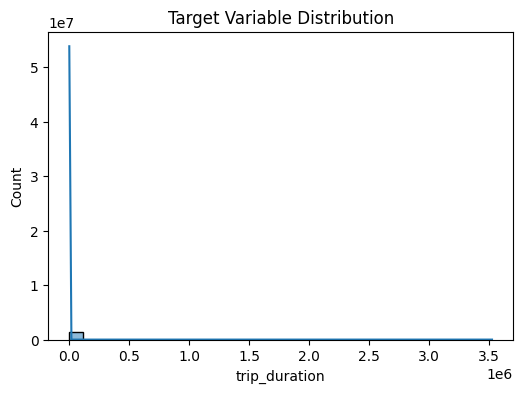

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(dataset['trip_duration'], kde=True,bins=30)
plt.title('Target Variable Distribution')
plt.show()

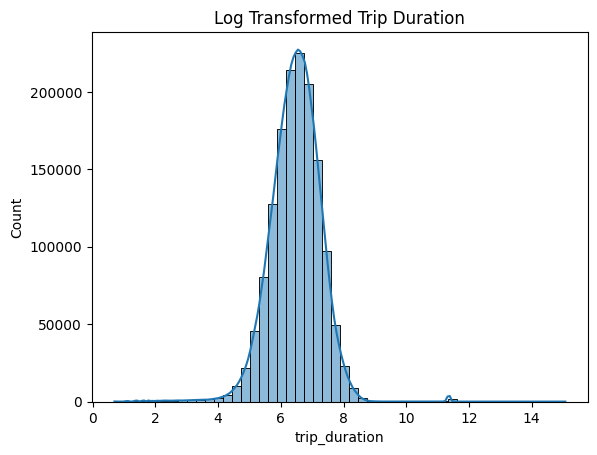

In [13]:
sns.histplot(np.log1p(dataset['trip_duration']), bins=50, kde=True)
plt.title("Log Transformed Trip Duration")
plt.show()

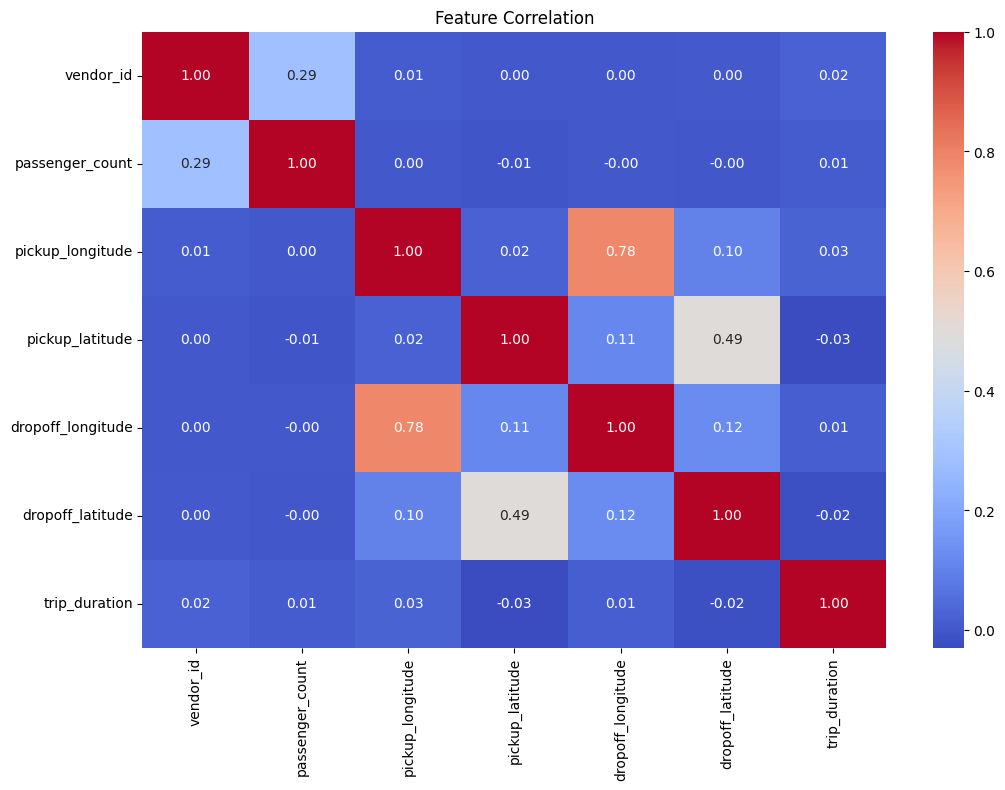

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

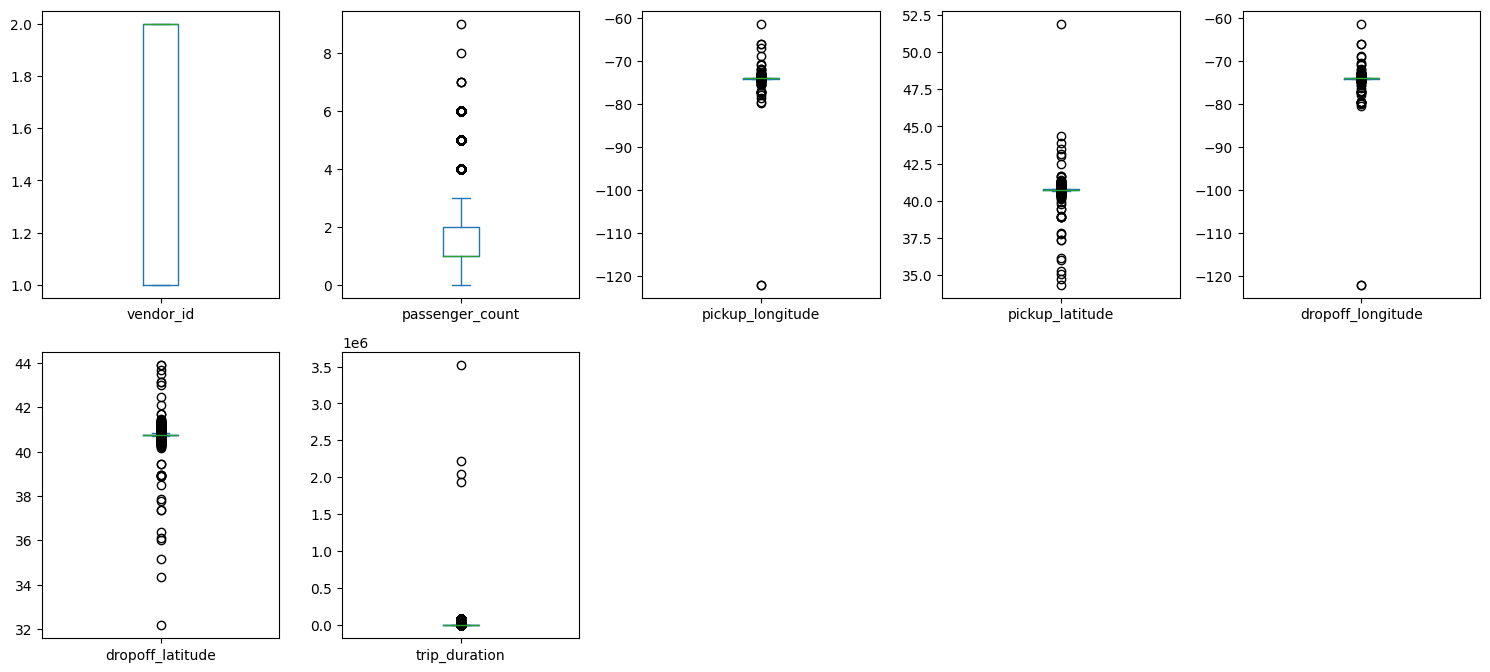

In [15]:
dataset.select_dtypes(include='number').plot(
    kind='box', 
    subplots=True, 
    figsize=(15,10),
    layout=(3,5))
plt.tight_layout()
plt.show()

In [16]:
cat_cols=dataset.select_dtypes(exclude=np.number).columns
cat_cols=list(cat_cols)
print(cat_cols)

['pickup_datetime', 'dropoff_datetime', 'store_and_fwd_flag']


In [17]:
q_low = dataset['trip_duration'].quantile(0.01)
q_high = dataset['trip_duration'].quantile(0.99)

dataset = dataset[(dataset['trip_duration'] >= q_low) & (dataset['trip_duration'] <= q_high)]
#noise removal
dataset = dataset[(dataset['trip_duration'] > 60) & (dataset['trip_duration'] < 14400)]

In [18]:
X = dataset.drop(['trip_duration','dropoff_datetime'], axis=1)
y = dataset['trip_duration']

In [19]:
dataset.shape

(1429538, 10)

In [20]:
X.shape

(1429538, 8)

In [21]:
y.shape

(1429538,)

In [22]:
from sklearn.model_selection import train_test_split
X_train ,X_test ,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=0  )

In [23]:
X_train.shape

(1143630, 8)

In [24]:
y_train.shape

(1143630,)

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin

class PreprocessTransformer(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, d):
        d = d.copy()
        
        # datetime
        d['pickup_datetime'] = pd.to_datetime(d['pickup_datetime']) 
        
        d['pickup_hour'] = d['pickup_datetime'].dt.hour
        d['day_of_week'] = d['pickup_datetime'].dt.dayofweek
        d['month'] = d['pickup_datetime'].dt.month         # NEW
        d['day_of_month'] = d['pickup_datetime'].dt.day    # NEW
        d['is_weekend'] = d['day_of_week'].apply(lambda x: 1 if x > 5 else 0)
        d['is_rush_hour'] = d['pickup_hour'].isin([7,8,9,10,16,17,18,19,20]).astype(int)
        d['is_night']     = d['pickup_hour'].isin([22,23,0,1,2,3,4]).astype(int)  # NEW

        d['hour_sin'] = np.sin(2 * np.pi * d['pickup_hour'] / 24)
        d['hour_cos'] = np.cos(2 * np.pi * d['pickup_hour'] / 24)
        d['dow_sin']  = np.sin(2 * np.pi * d['day_of_week'] / 7)
        d['dow_cos']  = np.cos(2 * np.pi * d['day_of_week'] / 7)

        # haversine
        def haversine(lat1, lon1, lat2, lon2):
            R = 6371
            lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
            dlat = lat2 - lat1
            dlon = lon2 - lon1
            a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
            c = 2 * np.arcsin(np.sqrt(a))
            return R * c

        def manhattan(lat1, lon1, lat2, lon2):
            return (
                haversine(lat1, lon1, lat2, lon1) +
                haversine(lat2, lon1, lat2, lon2)
            )

        def bearing(lat1, lon1, lat2, lon2):
            lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
            dlon = lon2 - lon1
            x = np.sin(dlon) * np.cos(lat2)
            y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
            angle = np.degrees(np.arctan2(x, y))
            return (angle + 360) % 360

        d['haversine_km'] = haversine(
            d['pickup_latitude'], d['pickup_longitude'],
            d['dropoff_latitude'], d['dropoff_longitude']
        )
        
        d['manhattan_km'] = manhattan(
            d['pickup_latitude'], d['pickup_longitude'],
            d['dropoff_latitude'], d['dropoff_longitude']
        )
        dataset['bearing'] = bearing(
            dataset['pickup_latitude'], dataset['pickup_longitude'],
            dataset['dropoff_latitude'], dataset['dropoff_longitude']
        )
        
        d['route_ratio'] = d['manhattan_km'] / (d['haversine_km'] + 1e-5)
    
    
        # flag encoding
        d['store_and_fwd_flag'] = (
            d['store_and_fwd_flag']
            .astype(str)
            .str.strip()
            .str.lower()
            .map({'y':1, 'n':0})
            .fillna(0)
        )

        d.drop(['pickup_latitude', 'pickup_longitude',
                'dropoff_latitude', 'dropoff_longitude',
                'pickup_datetime'], axis=1, inplace=True)
        
        if 'dropoff_datetime' in d.columns:
            d.drop('dropoff_datetime', axis=1, inplace=True)

        return d

In [26]:
from sklearn.base import BaseEstimator, TransformerMixin
class OutlierHandling(BaseEstimator, TransformerMixin):
    
    def __init__(self, columns, lower_quantile=0.01, upper_quantile=0.99):
        self.columns = columns
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
        self.bounds = {}
    
    def fit(self, X, y=None):
        X = X.copy()
        
        for col in self.columns:
            lower = X[col].quantile(self.lower_quantile)
            upper = X[col].quantile(self.upper_quantile)
            
            self.bounds[col] = (lower, upper)
        
        return self
    
    def transform(self, X):
        X = X.copy()
        
        for col in self.columns:
            lower, upper = self.bounds[col]
            X[col] = X[col].clip(lower, upper)
        
        return X

In [29]:
def fare_estimate(pipeline, dataset, pred_duration):
    base_fare = 2.5
    
    # preprocess se DataFrame le lo (already columns ke saath aa raha hai)
    processed = pipeline.named_steps['preprocess'].transform(dataset)
    
    # direct column access (no KeyError now)
    distance = processed['haversine_km'].iloc[0]
    
    time = pred_duration / 60  
    rush = processed['is_rush_hour'].iloc[0]
    passenger_count = processed['passenger_count'].iloc[0]
    hour = processed['pickup_hour'].iloc[0]
    
    fare = base_fare + (distance * 1.5) + (time * 0.5)
    
    if rush == 1:
        fare *= 1.2
    
    if hour >= 20 or hour <= 6:
        fare += 1.0
    
    fare += passenger_count * 0.5

    final_fare=round(max(fare, 3.0), 2)
    print("Estimated Fare ($):", round(final_fare, 2))
    print("Estimated distance (km):", round(distance, 2))
    
    return round(distance, 2)

In [32]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

pipe = Pipeline([
    ("preprocess", PreprocessTransformer()),
    ("outlier", OutlierHandling(columns=['haversine_km', 'manhattan_km'])),
    ("model", XGBRegressor())
])

final_model = TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,
    inverse_func=np.expm1
)


In [63]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "regressor__model__n_estimators": [200, 300, 400, 600],
    "regressor__model__max_depth": [4, 6, 8, 10],
    "regressor__model__learning_rate": [0.01, 0.05, 0.1],
    "regressor__model__subsample": [0.6, 0.8, 1.0],
    "regressor__model__colsample_bytree": [0.6, 0.8, 1.0],
    "regressor__model__min_child_weight": [1, 3, 5],
    "regressor__model__reg_alpha": [0, 0.01, 0.1, 1],
    "regressor__model__reg_lambda": [0.1, 1, 10],
    "regressor__model__gamma": [0, 0.1, 0.3, 1]

}

random = RandomizedSearchCV(
    final_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',#iss basis pai best estimator choose hota hai
    n_jobs=-1,
    random_state=42
)

random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","TransformedTa...None, ...))]))"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__model__colsample_bytree': [0.6, 0.8, ...], 'regressor__model__gamma': [0, 0.1, ...], 'regressor__model__learning_rate': [0.01, 0.05, ...], 'regressor__model__max_depth': [4, 6, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls

In [64]:
print("Best Parameters are:",random.best_params_)
best_model = random.best_estimator_
y_pred =best_model.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate(
    (y_pred.reshape(-1,1), y_test.to_numpy().reshape(-1,1)),axis=1))

Best Parameters are: {'regressor__model__subsample': 1.0, 'regressor__model__reg_lambda': 0.1, 'regressor__model__reg_alpha': 0.1, 'regressor__model__n_estimators': 400, 'regressor__model__min_child_weight': 3, 'regressor__model__max_depth': 10, 'regressor__model__learning_rate': 0.05, 'regressor__model__gamma': 0, 'regressor__model__colsample_bytree': 1.0}
[[ 479.72  435.  ]
 [1335.94 1165.  ]
 [1566.2  1826.  ]
 ...
 [ 725.26  658.  ]
 [ 615.53  765.  ]
 [ 974.48 1320.  ]]


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R2 score : {r2:,.2f}")

print(f"R2 Score(%): {r2 * 100:.2f} %")

MAE  : 203.38
MSE  : 89,066.40
RMSE : 298.44
R2 score : 0.73
R2 Score(%): 72.73 %


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "regressor__model__n_estimators": [200, 300, 400],
    "regressor__model__max_depth": [4, 6, 8],
    "regressor__model__learning_rate": [0.01, 0.05],
    "regressor__model__subsample": [0.6, 0.8, 1.0],
    "regressor__model__colsample_bytree": [0.6, 0.8, 1.0],
    "regressor__model__min_child_weight": [1, 3, 5],
    "regressor__model__reg_alpha": [0, 0.01, 0.1, 1],
    "regressor__model__reg_lambda": [0.1, 1, 10],
    "regressor__model__gamma": [0, 0.1, 0.3, 1]
}

grid = GridSearchCV(
    final_model,
    param_grid=param_grid,
    cv=2,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

In [33]:
final_model.get_params().keys()

dict_keys(['check_inverse', 'func', 'inverse_func', 'regressor__memory', 'regressor__steps', 'regressor__transform_input', 'regressor__verbose', 'regressor__preprocess', 'regressor__outlier', 'regressor__model', 'regressor__outlier__columns', 'regressor__outlier__lower_quantile', 'regressor__outlier__upper_quantile', 'regressor__model__objective', 'regressor__model__base_score', 'regressor__model__booster', 'regressor__model__callbacks', 'regressor__model__colsample_bylevel', 'regressor__model__colsample_bynode', 'regressor__model__colsample_bytree', 'regressor__model__device', 'regressor__model__early_stopping_rounds', 'regressor__model__enable_categorical', 'regressor__model__eval_metric', 'regressor__model__feature_types', 'regressor__model__feature_weights', 'regressor__model__gamma', 'regressor__model__grow_policy', 'regressor__model__importance_type', 'regressor__model__interaction_constraints', 'regressor__model__learning_rate', 'regressor__model__max_bin', 'regressor__model__ma

In [34]:
import optuna
from sklearn.model_selection import cross_val_score


   
def objective(trial):
    params = {
        "regressor__model__n_estimators":     trial.suggest_int("regressor__model__n_estimators", 400, 1200),
        "regressor__model__max_depth":        trial.suggest_int("regressor__model__max_depth", 4, 10),
        "regressor__model__learning_rate":    trial.suggest_float("regressor__model__learning_rate", 0.01, 0.15, log=True),
        "regressor__model__subsample":        trial.suggest_float("regressor__model__subsample", 0.6, 1.0),
        "regressor__model__colsample_bytree": trial.suggest_float("regressor__model__colsample_bytree", 0.6, 1.0),
        "regressor__model__min_child_weight": trial.suggest_int("regressor__model__min_child_weight", 1, 10),
        "regressor__model__reg_alpha":        trial.suggest_float("regressor__model__reg_alpha", 1e-4, 10.0, log=True),
        "regressor__model__reg_lambda":       trial.suggest_float("regressor__model__reg_lambda", 1e-4, 10.0, log=True),
        "regressor__model__gamma":            trial.suggest_float("regressor__model__gamma", 0, 5)
    }
    model = final_model.set_params(**params)
    score = cross_val_score(model, X_train, y_train,
                            cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1).mean()
    return score


C:\Users\mehak\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

[I 2026-04-28 21:53:59,878] A new study created in memory with name: no-name-d7524705-e44c-4824-a3d2-1f6b0d01a2e4
[I 2026-04-28 21:54:51,958] Trial 0 finished with value: -303.9075215657552 and parameters: {'regressor__model__n_estimators': 446, 'regressor__model__max_depth': 7, 'regressor__model__learning_rate': 0.03943903210026564, 'regressor__model__subsample': 0.8340050939069089, 'regressor__model__colsample_bytree': 0.782260178545354, 'regressor__model__min_child_weight': 3, 'regressor__model__reg_alpha': 0.405125649447988, 'regressor__model__reg_lambda': 0.0006720892416912566, 'regressor__model__gamma': 2.9243347141996727}. Best is trial 0 with value: -303.9075215657552.
[I 2026-04-28 21:55:43,379] Trial 1 finished with value: -302.54405721028644 and parameters: {'regressor__model__n_estimators': 552, 'regressor__model__max_depth': 7, 'regressor__model__learning_rate': 0.10220916001468197, 'regressor__model__subsample': 0.6420760668595215, 'regressor__model__colsample_bytree': 0.

In [36]:
print(study.best_params)

{'regressor__model__n_estimators': 792, 'regressor__model__max_depth': 8, 'regressor__model__learning_rate': 0.0741941010432134, 'regressor__model__subsample': 0.8280697641816416, 'regressor__model__colsample_bytree': 0.6332594686958686, 'regressor__model__min_child_weight': 8, 'regressor__model__reg_alpha': 0.18905277937712237, 'regressor__model__reg_lambda': 0.0005272349220392984, 'regressor__model__gamma': 0.027338602803770318}


In [37]:
best_params = study.best_params

final_model.set_params(
    regressor__model__n_estimators=best_params["regressor__model__n_estimators"],
    regressor__model__max_depth=best_params["regressor__model__max_depth"],
    regressor__model__learning_rate=best_params["regressor__model__learning_rate"],
    regressor__model__subsample=best_params["regressor__model__subsample"],
    regressor__model__colsample_bytree=best_params["regressor__model__colsample_bytree"],
    regressor__model__min_child_weight=best_params["regressor__model__min_child_weight"],
    regressor__model__reg_alpha= best_params["regressor__model__reg_alpha"],
    regressor__model__reg_lambda=best_params["regressor__model__reg_lambda"],
    regressor__model__gamma=best_params["regressor__model__gamma"]
)

best_model = final_model
best_model.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.","Pipeline(step...=None, ...))])"
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,columns,"['haversine_km', 'manhattan_km']"
,lower_quantile,0.01
,upper_quantile,0.99
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None


In [38]:
y_pred = best_model.predict(X_test)

np.set_printoptions(precision=2)

print(
    np.concatenate(
        (y_pred.reshape(-1,1), y_test.to_numpy().reshape(-1,1)),
        axis=1
    )
)

[[ 462.14  435.  ]
 [1374.15 1165.  ]
 [1564.46 1826.  ]
 ...
 [ 719.6   658.  ]
 [ 656.76  765.  ]
 [ 993.55 1320.  ]]


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R2 score : {r2:,.2f}")

print(f"R2 Score(%): {r2 * 100:.2f} %")

MAE  : 203.24
MSE  : 88,984.15
RMSE : 298.30
R2 score : 0.73
R2 Score(%): 72.75 %


In [40]:
new_data = pd.DataFrame([{
    'vendor_id':1,            
    'pickup_datetime':'2016-06-12 00:43:35',     
    'dropoff_datetime':'2016-06-12 00:54:38',
    'passenger_count':1,   
    'pickup_longitude':-73.980415344238281 ,
    'pickup_latitude':40.738563537597656 ,  
    'dropoff_longitude':-73.999481201171875 ,   
    'dropoff_latitude':40.731151580810547 ,   
    'store_and_fwd_flag':'N'
}])

pred_duration= best_model.predict(new_data)
value = pred_duration.item()
print("Predicted trip duration (sec):", round(value, 2))
print("Predicted trip duration (min):", round(value / 60, 2))
fare_distance= fare_estimate(pipe, new_data, pred_duration.item())
time_hr=value/3600
speed=fare_distance/time_hr
print("Estimated speed (km/h):",round(speed,2))

Predicted trip duration (sec): 517.65
Predicted trip duration (min): 8.63
Estimated Fare ($): 11.02
Estimated distance (km): 1.81
Estimated speed (km/h): 12.59


In [41]:
processed = pipe.named_steps['preprocess'].transform(new_data)
print(processed)

   vendor_id  passenger_count  store_and_fwd_flag  pickup_hour  day_of_week  \
0          1                1                   0            0            6   

   month  day_of_month  is_weekend  is_rush_hour  is_night  hour_sin  \
0      6            12           1             0         1       0.0   

   hour_cos   dow_sin  dow_cos  haversine_km  manhattan_km  route_ratio  
0       1.0 -0.781831  0.62349      1.805507      2.430685     1.346254  


In [43]:
import pickle#just save the name not the code
pickle.dump(best_model, open('best_model.pkl', 'wb'))
pickle.dump(pipe, open('pipe.pkl', 'wb'))
print("Model saved!")

Model saved!
